# Latent DiT Diagnostics

이 노트북은 `data/03_features -> checkpoints -> data/04_predictions` 단계가 실제로 원하는 방식으로 동작하는지 검증합니다.

주요 질문은 세 가지입니다.

1. `E_c`를 바꾸면 DiT 출력이 의미 있게 달라지는가?
2. 생성된 `E_v_hat`의 분포가 실제 `E_v` latent 분포와 비슷한가?
3. 현재 anomaly score가 정상/이상을 올바른 방향으로 분리하는가?

production 코드는 수정하지 않고, 기존 pipeline/model 함수를 import해서 같은 checkpoint, 같은 diffusion schedule, 같은 scoring 함수를 사용합니다.

## 실행 전 설정

- `RUN_ID`는 `checkpoints/<RUN_ID>/best.pt`와 `data/04_predictions/shanghaitech/<RUN_ID>`를 가리킵니다.
- `LIMIT_SAMPLES`와 `BATCH_SIZE`를 낮추면 빠르게 검증할 수 있습니다.
- `INFERENCE_STEPS_OVERRIDE = None`이면 config의 DDIM step을 그대로 씁니다. 빠른 sanity check만 하려면 10 또는 20으로 줄이세요.
- `SAVE_REPORT = True`이면 `data/04_predictions/.../diagnostics_report.json`에 요약을 저장합니다.

In [8]:
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook fallback
    display = print

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RUN_ID = os.environ.get("VAD_RUN_ID", "exp001")
CONFIG_PATH = PROJECT_ROOT / "config" / "local.yaml"
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / RUN_ID / "best.pt"
PRED_DIR = PROJECT_ROOT / "data" / "04_predictions" / "shanghaitech" / RUN_ID

LIMIT_SAMPLES = int(os.environ.get("VAD_DIAGNOSTIC_LIMIT", "16"))
BATCH_SIZE = int(os.environ.get("VAD_DIAGNOSTIC_BATCH_SIZE", "4"))
INFERENCE_STEPS_OVERRIDE: int | None = None
DIAGNOSTIC_SEED = 42
SAVE_REPORT = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROCESS = psutil.Process(os.getpid())

torch.set_grad_enabled(False)

print(f"project_root={PROJECT_ROOT}")
print(f"run_id={RUN_ID}")
print(f"device={DEVICE}")
print(f"config={CONFIG_PATH}")
print(f"checkpoint={CHECKPOINT_PATH}")
print(f"pred_dir={PRED_DIR}")

project_root=/workspace/VAD
run_id=exp001
device=cuda
config=/workspace/VAD/config/local.yaml
checkpoint=/workspace/VAD/checkpoints/exp001/best.pt
pred_dir=/workspace/VAD/data/04_predictions/shanghaitech/exp001


In [9]:
from torch.utils.data import DataLoader

from src.pipelines.latent_dit_pipeline import (
    FeatureLatentDataset,
    aggregate_frame_scores,
    amp_is_enabled,
    build_flow_matching_sampler,
    compute_binary_metrics,
    load_feature_records,
    load_flow_matching_config,
    load_pipeline_config,
    make_loader_kwargs,
    move_feature_batch,
    per_frame_latent_scores,
    torch_dtype,
)
from src.pipelines.training_pipeline import configure_torch_backend, load_checkpoint_for_inference

In [10]:
def project_path(path: str | Path | None) -> Path | None:
    if path is None:
        return None
    resolved = Path(path)
    if resolved.is_absolute():
        return resolved
    return PROJECT_ROOT / resolved


def normalize_feature_record_paths(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    normalized = []
    for record in records:
        item = dict(record)
        for key in ("context_feature_path", "future_latent_path"):
            if key in item:
                item[key] = str(project_path(item[key]))
        normalized.append(item)
    return normalized


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    if not path.is_file():
        return []
    with path.open("r", encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]


def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, sort_keys=True)
        file.write(chr(10))


def fallback_roc_auc(labels: np.ndarray, scores: np.ndarray) -> float:
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores).astype(float)
    pos_count = int((labels == 1).sum())
    neg_count = int((labels == 0).sum())
    if pos_count == 0 or neg_count == 0:
        return float("nan")
    ranks = pd.Series(scores).rank(method="average").to_numpy()
    pos_rank_sum = ranks[labels == 1].sum()
    auc = (pos_rank_sum - pos_count * (pos_count + 1) / 2) / (pos_count * neg_count)
    return float(auc)


def fallback_average_precision(labels: np.ndarray, scores: np.ndarray) -> float:
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores).astype(float)
    pos_count = int((labels == 1).sum())
    if pos_count == 0:
        return float("nan")
    order = np.argsort(-scores, kind="mergesort")
    sorted_labels = labels[order]
    precision = np.cumsum(sorted_labels) / np.arange(1, len(sorted_labels) + 1)
    return float((precision * sorted_labels).sum() / pos_count)


def score_metrics(labels: np.ndarray, scores: np.ndarray) -> dict[str, float]:
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores).astype(float)
    return {
        "roc_auc": fallback_roc_auc(labels, scores),
        "average_precision": fallback_average_precision(labels, scores),
        "inverted_roc_auc": fallback_roc_auc(labels, -scores),
        "inverted_average_precision": fallback_average_precision(labels, -scores),
        "normal_mean": float(scores[labels == 0].mean()) if (labels == 0).any() else float("nan"),
        "anomaly_mean": float(scores[labels == 1].mean()) if (labels == 1).any() else float("nan"),
        "num_frames": int(len(labels)),
        "num_anomaly_frames": int(labels.sum()),
    }


MAX_STAT_VALUES = 1_000_000


def tensor_stats(name: str, tensor: torch.Tensor) -> dict[str, Any]:
    x = tensor.detach().float().cpu()
    flat = x.flatten()
    if flat.numel() > MAX_STAT_VALUES:
        step = max(1, flat.numel() // MAX_STAT_VALUES)
        quantile_flat = flat[::step][:MAX_STAT_VALUES]
    else:
        quantile_flat = flat
    return {
        "name": name,
        "shape": list(x.shape),
        "num_values": int(flat.numel()),
        "quantile_values_used": int(quantile_flat.numel()),
        "mean": float(x.mean()),
        "std": float(x.std(unbiased=False)),
        "min": float(x.min()),
        "p01": float(torch.quantile(quantile_flat, 0.01)),
        "p50": float(torch.quantile(quantile_flat, 0.50)),
        "p99": float(torch.quantile(quantile_flat, 0.99)),
        "max": float(x.max()),
        "rms": float(torch.sqrt(torch.mean(x.square()))),
    }


def tensor_mse(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.detach().float() - b.detach().float()).square().mean().cpu())


def tensor_mae(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.detach().float() - b.detach().float()).abs().mean().cpu())


def set_torch_seed(seed: int) -> None:
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_context_variant(context: torch.Tensor, mode: str) -> torch.Tensor:
    if mode == "real":
        return context
    if mode == "zero":
        return torch.zeros_like(context)
    if mode == "shuffled":
        if context.shape[0] > 1:
            order = torch.roll(torch.arange(context.shape[0], device=context.device), shifts=1)
            return context.index_select(0, order)
        return context.roll(shifts=1, dims=2)
    if mode == "time_reversed":
        return context.flip(1)
    raise ValueError(f"unknown context mode: {mode}")


def current_memory_mb() -> float:
    return PROCESS.memory_info().rss / (1024**2)


def cuda_memory_mb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / (1024**2)


diagnostic_report: dict[str, Any] = {}

## 1. 기존 prediction 결과 방향성 확인

먼저 이미 생성된 `frame_scores.jsonl` 기준으로 score 방향을 확인합니다. anomaly score라면 보통 이상 프레임 평균이 정상 프레임 평균보다 높고, ROC-AUC가 0.5보다 커야 합니다.

In [11]:
frame_scores_path = PRED_DIR / "frame_scores.jsonl"
future_predictions_path = PRED_DIR / "future_frame_predictions.jsonl"
metrics_path = PRED_DIR / "metrics.json"

frame_scores = pd.DataFrame(read_jsonl(frame_scores_path))
future_predictions = pd.DataFrame(read_jsonl(future_predictions_path))

if metrics_path.is_file():
    with metrics_path.open("r", encoding="utf-8") as file:
        stored_metrics = json.load(file)
else:
    stored_metrics = {}

print(f"frame_scores rows={len(frame_scores):,} path={frame_scores_path}")
print(f"future prediction rows={len(future_predictions):,} path={future_predictions_path}")
print(f"stored metrics={stored_metrics}")

if not frame_scores.empty and {"label", "score"}.issubset(frame_scores.columns):
    existing_summary = score_metrics(frame_scores["label"].to_numpy(), frame_scores["score"].to_numpy())
    display(pd.DataFrame([existing_summary]))
    diagnostic_report["existing_prediction_summary"] = existing_summary
else:
    existing_summary = {}
    print("frame_scores.jsonl이 없거나 label/score 컬럼이 없습니다. inference를 먼저 실행하세요.")

frame_scores rows=37,260 path=/workspace/VAD/data/04_predictions/shanghaitech/exp001/frame_scores.jsonl
future prediction rows=9,208 path=/workspace/VAD/data/04_predictions/shanghaitech/exp001/future_frame_predictions.jsonl
stored metrics={'average_precision': None, 'checkpoint_path': 'checkpoints/exp001/best.pt', 'metrics_error': 'scikit-learn is not installed', 'num_anomaly_frames': 16972, 'num_frames': 37260, 'prediction_records': 9208, 'roc_auc': None, 'run_id': 'exp001'}


,roc_auc,average_precision,inverted_roc_auc,inverted_average_precision,normal_mean,anomaly_mean,num_frames,num_anomaly_frames
0,0.42121,0.394998,0.57879,0.507325,1.729172e+06,1.698067e+06,37260,16972


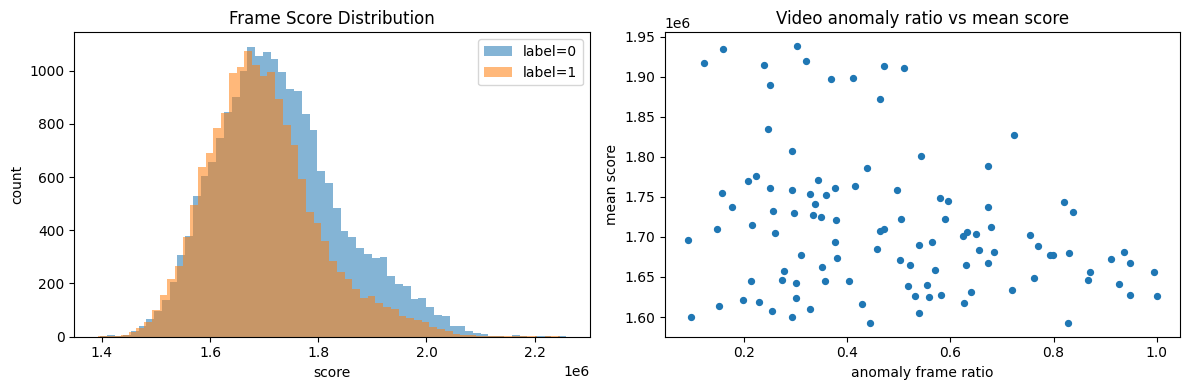

,video_id,frames,anomaly_ratio,mean_score,max_score
40,03_0035,352,0.301136,1.938025e+06,2.113373e+06
46,03_0061,208,0.158654,1.934477e+06,2.120380e+06
38,03_0032,376,0.319149,1.918961e+06,2.107965e+06
37,03_0031,496,0.120968,1.916459e+06,2.192141e+06
45,03_0060,352,0.238636,1.915051e+06,2.258384e+06
42,03_0039,448,0.470982,1.913405e+06,2.130024e+06
41,03_0036,424,0.509434,1.910554e+06,2.089628e+06
39,03_0033,280,0.410714,1.898345e+06,2.122767e+06
44,03_0059,400,0.367500,1.896558e+06,2.066735e+06
43,03_0041,424,0.250000,1.889472e+06,2.142785e+06


In [12]:
if not frame_scores.empty and {"label", "score"}.issubset(frame_scores.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, group in frame_scores.groupby("label"):
        axes[0].hist(group["score"], bins=60, alpha=0.55, label=f"label={label}")
    axes[0].set_title("Frame Score Distribution")
    axes[0].set_xlabel("score")
    axes[0].set_ylabel("count")
    axes[0].legend()

    video_summary = (
        frame_scores.groupby("video_id")
        .agg(
            frames=("frame_idx", "count"),
            anomaly_ratio=("label", "mean"),
            mean_score=("score", "mean"),
            max_score=("score", "max"),
        )
        .reset_index()
    )
    axes[1].scatter(video_summary["anomaly_ratio"], video_summary["mean_score"], s=18)
    axes[1].set_title("Video anomaly ratio vs mean score")
    axes[1].set_xlabel("anomaly frame ratio")
    axes[1].set_ylabel("mean score")
    plt.tight_layout()
    plt.show()

    display(video_summary.sort_values("mean_score", ascending=False).head(10))

## 2. Checkpoint, feature batch 로드

여기부터는 `data/03_features`의 실제 `E_c`, `E_v`와 checkpoint를 로드해서 즉석으로 검증합니다.

In [13]:
if not CONFIG_PATH.is_file():
    raise FileNotFoundError(f"Missing config: {CONFIG_PATH}")
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"Missing checkpoint: {CHECKPOINT_PATH}. RUN_ID를 바꾸거나 학습을 먼저 실행하세요."
    )

config = load_pipeline_config(CONFIG_PATH)
configure_torch_backend(config.optimization.matmul_precision)

feature_index_path = project_path(config.inference.feature_index)
assert feature_index_path is not None
records = load_feature_records(feature_index_path, normal_only=False, limit_samples=LIMIT_SAMPLES)
records = normalize_feature_record_paths(records)
dataset = FeatureLatentDataset(records)
loader = DataLoader(
    dataset,
    **make_loader_kwargs(
        batch_size=min(BATCH_SIZE, len(dataset)),
        num_workers=0,
        shuffle=False,
    ),
)
batch = next(iter(loader))

model, latent_stats, checkpoint_config = load_checkpoint_for_inference(CHECKPOINT_PATH, device=DEVICE)
checkpoint_flow_config = load_flow_matching_config(checkpoint_config["flow_matching"])
flow = build_flow_matching_sampler(checkpoint_flow_config)

context, future = move_feature_batch(batch, DEVICE)
active_inference_steps = (
    config.flow_matching.inference_steps
    if INFERENCE_STEPS_OVERRIDE is None
    else int(INFERENCE_STEPS_OVERRIDE)
)

shape_summary = pd.DataFrame(
    [
        tensor_stats("E_c_context", context),
        tensor_stats("E_v_future", future),
        tensor_stats("latent_stats_mean", latent_stats["mean"]),
        tensor_stats("latent_stats_std", latent_stats["std"]),
    ]
)
print(f"feature_index={feature_index_path}")
print(f"records_loaded={len(records):,}")
print(f"active_inference_steps={active_inference_steps}")
print(f"rss_memory_mb={current_memory_mb():.1f}")
display(shape_summary)

diagnostic_report["loaded_batch"] = {
    "feature_index": str(feature_index_path),
    "records_loaded": len(records),
    "batch_size": int(context.shape[0]),
    "context_shape": list(context.shape),
    "future_shape": list(future.shape),
    "active_inference_steps": active_inference_steps,
}

feature_index=/workspace/VAD/data/03_features/shanghaitech/test_feature_index.jsonl
records_loaded=16
active_inference_steps=50
rss_memory_mb=933.5


,name,shape,num_values,quantile_values_used,mean,std,min,p01,p50,p99,max,rms
0,E_c_context,"[4, 32, 256, 768]",25165824,1000000,0.002572,2.114258,-72.437500,-2.242188,-0.010468,2.359375,486.250000,2.114259
1,E_v_future,"[4, 8, 4, 32, 32]",131072,131072,0.104825,0.580227,-1.951172,-1.350586,0.128174,1.452148,2.345703,0.589620
2,latent_stats_mean,"[1, 1, 4, 1, 1]",4,4,0.137924,0.205609,-0.183927,-0.175303,0.199275,0.335813,0.337075,0.247585
3,latent_stats_std,"[1, 1, 4, 1, 1]",4,4,0.664364,0.085776,0.577141,0.578154,0.639138,0.798001,0.802041,0.669879


In [14]:
metadata_preview = pd.DataFrame(batch["metadata"])
preview_columns = [
    column
    for column in [
        "sample_id",
        "video_id",
        "scene_id",
        "context_frames",
        "future_frames",
        "future_frame_labels",
        "future_label",
    ]
    if column in metadata_preview.columns
]
display(metadata_preview[preview_columns].head())

,sample_id,video_id,scene_id,context_frames,future_frames,future_frame_labels,future_label
0,01_0014_000001_000033,01_0014,scene_01,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[33, 34, 35, 36, 37, 38, 39, 40]","[0, 0, 0, 0, 0, 0, 0, 0]",0
1,01_0014_000005_000037,01_0014,scene_01,"[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17...","[37, 38, 39, 40, 41, 42, 43, 44]","[0, 0, 0, 0, 0, 0, 0, 0]",0
2,01_0014_000009_000041,01_0014,scene_01,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...","[41, 42, 43, 44, 45, 46, 47, 48]","[0, 0, 0, 0, 0, 0, 0, 0]",0
3,01_0014_000013_000045,01_0014,scene_01,"[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 2...","[45, 46, 47, 48, 49, 50, 51, 52]","[0, 0, 0, 0, 0, 0, 0, 0]",0


## 3. Context adapter 입력 민감도

`E_c`가 모델 안에서 조건 token으로 변환될 때 실제 context와 zero/shuffled context가 얼마나 다른지 확인합니다. 여기서 차이가 거의 없으면 adapter 단계부터 조건 정보가 약합니다.

In [15]:
with torch.inference_mode():
    context_tokens_real = model.context_adapter(make_context_variant(context, "real"))
    context_tokens_zero = model.context_adapter(make_context_variant(context, "zero"))
    context_tokens_shuffled = model.context_adapter(make_context_variant(context, "shuffled"))

context_adapter_summary = pd.DataFrame(
    [
        tensor_stats("context_tokens_real", context_tokens_real),
        tensor_stats("context_tokens_zero", context_tokens_zero),
        tensor_stats("context_tokens_shuffled", context_tokens_shuffled),
    ]
)
context_adapter_delta = pd.DataFrame(
    [
        {
            "comparison": "real_vs_zero",
            "mse": tensor_mse(context_tokens_real, context_tokens_zero),
            "mae": tensor_mae(context_tokens_real, context_tokens_zero),
        },
        {
            "comparison": "real_vs_shuffled",
            "mse": tensor_mse(context_tokens_real, context_tokens_shuffled),
            "mae": tensor_mae(context_tokens_real, context_tokens_shuffled),
        },
    ]
)

display(context_adapter_summary)
display(context_adapter_delta)

diagnostic_report["context_adapter_summary"] = context_adapter_summary.to_dict("records")
diagnostic_report["context_adapter_delta"] = context_adapter_delta.to_dict("records")

,name,shape,num_values,quantile_values_used,mean,std,min,p01,p50,p99,max,rms
0,context_tokens_real,"[4, 512, 384]",786432,786432,0.000319,0.986688,-5.309333,-2.395488,-0.008900,2.474787,6.755640,0.986688
1,context_tokens_zero,"[4, 512, 384]",786432,786432,0.000356,0.981536,-4.248351,-2.269487,0.001186,2.291075,4.676621,0.981536
2,context_tokens_shuffled,"[4, 512, 384]",786432,786432,0.000319,0.986688,-5.309333,-2.395488,-0.008900,2.474787,6.755640,0.986688


,comparison,mse,mae
0,real_vs_zero,1.620452,1.006340
1,real_vs_shuffled,0.104001,0.198564


## 4. 실제 Euler flow sampling으로 `E_v_hat` 분포 확인

현재 inference와 같은 방식으로 `E_v_hat`을 생성한 뒤, 실제 `E_v`와 scale, MSE, cosine similarity를 비교합니다.

- `E_v_hat`의 RMS/std가 실제 `E_v`보다 크게 튀면 flow sampling 또는 velocity scale 문제가 큽니다.
- flow matching은 DDIM의 `1 / sqrt(alpha_bar)` 폭주 구조가 없으므로, 이 비율이 크게 튄다면 학습/normalization/velocity 예측 문제를 먼저 봅니다.

In [16]:
def autocast_context():
    return torch.amp.autocast(
        device_type=DEVICE.type,
        dtype=torch_dtype(config.training.dtype),
        enabled=False,
    )


@torch.inference_mode()
def generate_prediction(context_mode: str, seed: int) -> torch.Tensor:
    set_torch_seed(seed)
    ctx = make_context_variant(context, context_mode)
    return flow.euler_sample(
        model,
        ctx,
        tuple(future.shape),
        latent_stats=latent_stats,
        inference_steps=active_inference_steps,
    )


def per_future_metric_table(prediction: torch.Tensor, variant: str) -> pd.DataFrame:
    raw_mse = (future.float() - prediction.float()).square().mean(dim=(2, 3, 4)).detach().cpu()
    configured_scores = per_frame_latent_scores(
        future,
        prediction,
        scoring=config.scoring,
        latent_stats=latent_stats,
    ).detach().cpu()
    cosine = torch.nn.functional.cosine_similarity(
        future.float().flatten(2),
        prediction.float().flatten(2),
        dim=2,
    ).detach().cpu()
    rows = []
    for offset in range(future.shape[1]):
        rows.append(
            {
                "variant": variant,
                "future_offset": offset + 1,
                "raw_mse_mean": float(raw_mse[:, offset].mean()),
                "raw_mse_std": float(raw_mse[:, offset].std(unbiased=False)),
                "configured_score_mean": float(configured_scores[:, offset].mean()),
                "configured_score_std": float(configured_scores[:, offset].std(unbiased=False)),
                "cosine_mean": float(cosine[:, offset].mean()),
                "cosine_std": float(cosine[:, offset].std(unbiased=False)),
            }
        )
    return pd.DataFrame(rows)

start = time.perf_counter()
pred_real = generate_prediction("real", seed=DIAGNOSTIC_SEED)
elapsed = time.perf_counter() - start

latent_distribution = pd.DataFrame(
    [
        tensor_stats("real_E_v", future),
        tensor_stats("pred_E_v_hat_real_context", pred_real),
        tensor_stats("error_real_context", future - pred_real),
    ]
)
metric_real = per_future_metric_table(pred_real, "real_context")

print(f"generation_elapsed_sec={elapsed:.2f}")
print(f"cuda_max_memory_mb={cuda_memory_mb():.1f}")
display(latent_distribution)
display(metric_real)

diagnostic_report["generation_elapsed_sec"] = elapsed
diagnostic_report["latent_distribution"] = latent_distribution.to_dict("records")
diagnostic_report["real_context_future_metrics"] = metric_real.to_dict("records")

generation_elapsed_sec=0.33
cuda_max_memory_mb=483.4


,name,shape,num_values,quantile_values_used,mean,std,min,p01,p50,p99,max,rms
0,real_E_v,"[4, 8, 4, 32, 32]",131072,131072,0.104825,0.580227,-1.951172,-1.350586,0.128174,1.452148,2.345703,0.589620
1,pred_E_v_hat_real_context,"[4, 8, 4, 32, 32]",131072,131072,128.995941,823.869446,-3549.585449,-1835.895630,137.048401,2037.753662,4058.296143,833.906982
2,error_real_context,"[4, 8, 4, 32, 32]",131072,131072,-128.891113,823.779846,-4057.589111,-2037.357056,-137.088364,1836.025024,3549.440186,833.802246


,variant,future_offset,raw_mse_mean,raw_mse_std,configured_score_mean,configured_score_std,cosine_mean,cosine_std
0,real_context,1,688299.3750,31813.539062,1597674.625,87945.578125,0.182042,0.031760
1,real_context,2,699468.9375,10718.796875,1617276.500,42454.933594,0.180780,0.040014
2,real_context,3,697786.5000,23764.281250,1613514.750,68219.640625,0.178180,0.037522
3,real_context,4,694937.5625,15108.488281,1612233.375,53405.277344,0.180168,0.049611
4,real_context,5,695864.7500,23206.613281,1613324.375,65097.128906,0.178157,0.042946
5,real_context,6,693156.6250,20000.656250,1604003.750,60047.187500,0.180344,0.043192
6,real_context,7,691017.8125,5150.291992,1600138.125,25680.074219,0.173949,0.048385
7,real_context,8,701277.6250,14290.912109,1626425.125,48293.765625,0.170033,0.040555


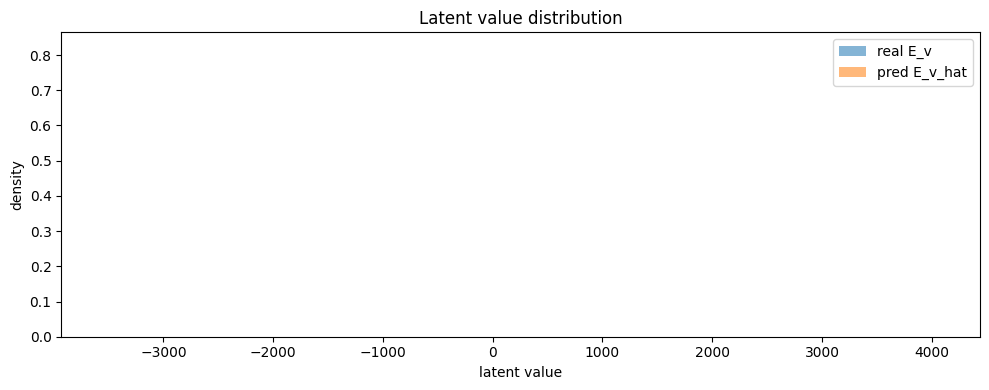

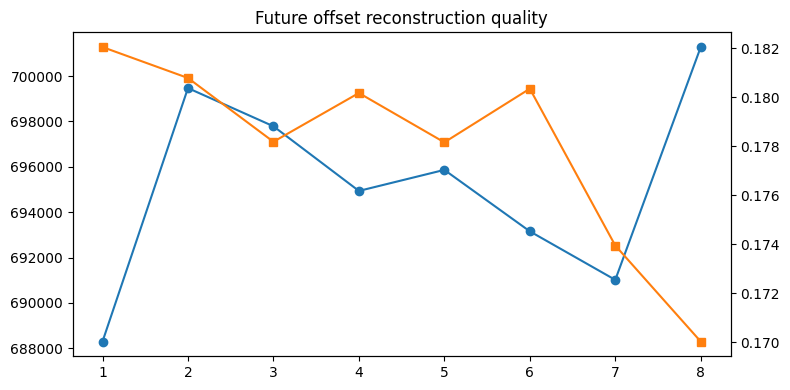

In [17]:
real_flat = future.detach().float().cpu().flatten().numpy()
pred_flat = pred_real.detach().float().cpu().flatten().numpy()

sample_limit = min(200_000, real_flat.size)
if real_flat.size > sample_limit:
    rng = np.random.default_rng(DIAGNOSTIC_SEED)
    sample_indices = rng.choice(real_flat.size, size=sample_limit, replace=False)
    real_plot = real_flat[sample_indices]
    pred_plot = pred_flat[sample_indices]
else:
    real_plot = real_flat
    pred_plot = pred_flat

plt.figure(figsize=(10, 4))
plt.hist(real_plot, bins=100, alpha=0.55, density=True, label="real E_v")
plt.hist(pred_plot, bins=100, alpha=0.55, density=True, label="pred E_v_hat")
plt.title("Latent value distribution")
plt.xlabel("latent value")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(metric_real["future_offset"], metric_real["raw_mse_mean"], marker="o", label="raw MSE")
plt.twinx()
plt.plot(
    metric_real["future_offset"],
    metric_real["cosine_mean"],
    marker="s",
    color="tab:orange",
    label="cosine",
)
plt.title("Future offset reconstruction quality")
plt.xlabel("future offset")
plt.tight_layout()
plt.show()

## 5. Context ablation: real vs zero vs shuffled

같은 초기 noise seed를 사용하고 context만 바꿔서 sampling합니다.

- `MSE(pred_real, pred_zero)`와 `MSE(pred_real, pred_shuffled)`가 `MSE(pred_real, E_v)`보다 너무 작으면, 출력이 context에 거의 반응하지 않는다는 뜻입니다.
- zero/shuffled context score가 real context score와 비슷하면 `E_c` 조건이 anomaly score에 거의 기여하지 않는 상태입니다.

In [18]:
context_modes = ["real", "zero", "shuffled", "time_reversed"]
predictions_by_context: dict[str, torch.Tensor] = {"real": pred_real}

for mode in tqdm(context_modes[1:], desc="context ablation sampling"):
    predictions_by_context[mode] = generate_prediction(mode, seed=DIAGNOSTIC_SEED)

ablation_rows = []
for mode, prediction in predictions_by_context.items():
    scores = per_frame_latent_scores(
        future,
        prediction,
        scoring=config.scoring,
        latent_stats=latent_stats,
    )
    ablation_rows.append(
        {
            "context_mode": mode,
            "mse_to_future": tensor_mse(prediction, future),
            "mae_to_future": tensor_mae(prediction, future),
            "configured_score_mean": float(scores.mean().detach().cpu()),
            "configured_score_std": float(scores.std(unbiased=False).detach().cpu()),
            "mse_to_real_context_prediction": tensor_mse(prediction, pred_real),
        }
    )

ablation_df = pd.DataFrame(ablation_rows)
base_error = float(ablation_df.loc[ablation_df["context_mode"] == "real", "mse_to_future"].iloc[0])
ablation_df["prediction_delta_vs_error"] = ablation_df["mse_to_real_context_prediction"] / max(
    base_error,
    1.0e-12,
)
display(ablation_df)

diagnostic_report["context_ablation"] = ablation_df.to_dict("records")

context ablation sampling: 100%|██████████| 3/3 [00:00<00:00,  4.28it/s]


,context_mode,mse_to_future,mae_to_future,configured_score_mean,configured_score_std,mse_to_real_context_prediction,prediction_delta_vs_error
0,real,6.952262e+05,663.398132,1610573.875,59698.796875,0.000000e+00,0.000000
1,zero,1.875833e+06,1092.984985,4391288.000,141512.343750,1.421199e+06,2.044225
2,shuffled,6.938281e+05,662.848999,1607459.500,61044.968750,7.326572e+03,0.010538
3,time_reversed,6.874672e+05,660.085327,1596528.750,62475.917969,1.030369e+04,0.014821


,variant,future_offset,raw_mse_mean,raw_mse_std,configured_score_mean,configured_score_std,cosine_mean,cosine_std
0,real,1,6.882994e+05,31813.539062,1597674.625,87945.578125,0.182042,0.031760
1,real,2,6.994689e+05,10718.796875,1617276.500,42454.933594,0.180780,0.040014
2,real,3,6.977865e+05,23764.281250,1613514.750,68219.640625,0.178180,0.037522
3,real,4,6.949376e+05,15108.488281,1612233.375,53405.277344,0.180168,0.049611
4,real,5,6.958648e+05,23206.613281,1613324.375,65097.128906,0.178157,0.042946
5,real,6,6.931566e+05,20000.656250,1604003.750,60047.187500,0.180344,0.043192
6,real,7,6.910178e+05,5150.291992,1600138.125,25680.074219,0.173949,0.048385
7,real,8,7.012776e+05,14290.912109,1626425.125,48293.765625,0.170033,0.040555
8,zero,1,1.866073e+06,65865.085938,4368032.500,159637.343750,0.081125,0.014696
9,zero,2,1.877066e+06,56197.500000,4401001.000,159374.828125,0.081041,0.020654


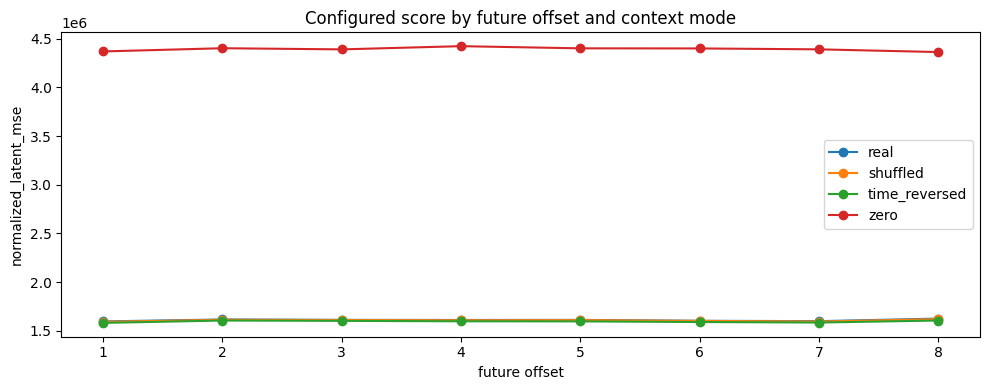

In [19]:
metric_tables = [per_future_metric_table(pred, mode) for mode, pred in predictions_by_context.items()]
metrics_by_context = pd.concat(metric_tables, ignore_index=True)
display(metrics_by_context)

plt.figure(figsize=(10, 4))
for mode, group in metrics_by_context.groupby("variant"):
    plt.plot(group["future_offset"], group["configured_score_mean"], marker="o", label=mode)
plt.title("Configured score by future offset and context mode")
plt.xlabel("future offset")
plt.ylabel(config.scoring.method)
plt.legend()
plt.tight_layout()
plt.show()

diagnostic_report["context_ablation_future_metrics"] = metrics_by_context.to_dict("records")

## 6. Flow velocity consistency 검증

이 검증은 sampling 전체를 돌리지 않고, 실제 `E_v`와 noise 사이의 중간 latent `Z_tau`에서 모델이 velocity target `Z_norm - sigma`를 맞히는지 봅니다.

- real context의 velocity MSE가 zero/shuffled보다 낮으면, 모델이 `E_c`를 조건으로 쓰고 있다는 신호입니다.
- velocity consistency는 괜찮은데 full Euler sampling만 나쁘면, integration step 수나 sampler 설정을 봅니다.
- velocity consistency도 zero/shuffled와 비슷하면 conditioning, 데이터 정렬, context adapter, 학습량을 먼저 봐야 합니다.

In [20]:
@torch.inference_mode()
def flow_consistency_table(tau_values: list[float]) -> pd.DataFrame:
    rows = []
    clean = flow.normalize(future, latent_stats)
    for tau_value in tqdm(tau_values, desc="flow velocity consistency"):
        tau = torch.full(
            (future.shape[0],),
            float(tau_value),
            device=DEVICE,
            dtype=torch.float32,
        )
        tau_view = tau.reshape(future.shape[0], *((1,) * (future.ndim - 1)))
        set_torch_seed(DIAGNOSTIC_SEED + int(round(float(tau_value) * 1000)))
        noise = torch.randn_like(clean)
        latents_at_tau = (1.0 - tau_view) * noise + tau_view * clean
        target_velocity = clean - noise
        for mode in context_modes:
            ctx = make_context_variant(context, mode)
            pred_velocity = model(latents_at_tau, flow.scale_time(tau), ctx).float()
            rows.append(
                {
                    "tau": float(tau_value),
                    "context_mode": mode,
                    "velocity_mse": tensor_mse(pred_velocity, target_velocity),
                    "velocity_mae": tensor_mae(pred_velocity, target_velocity),
                    "pred_velocity_rms": tensor_stats("pred_velocity", pred_velocity)["rms"],
                    "target_velocity_rms": tensor_stats("target_velocity", target_velocity)["rms"],
                }
            )
    return pd.DataFrame(rows)

probe_taus = [float(value) for value in np.linspace(0.0, 0.999, num=6)]
flow_df = flow_consistency_table(probe_taus)
display(flow_df)

flow_pivot = flow_df.pivot_table(
    index="tau",
    columns="context_mode",
    values="velocity_mse",
    aggfunc="mean",
)
for column in ["zero", "shuffled", "time_reversed"]:
    if column in flow_pivot.columns and "real" in flow_pivot.columns:
        flow_pivot[f"real_minus_{column}"] = flow_pivot["real"] - flow_pivot[column]

display(flow_pivot)

diagnostic_report["flow_velocity_consistency"] = flow_df.to_dict("records")

denoising consistency: 100%|██████████| 6/6 [00:01<00:00,  5.50it/s]


,timestep,context_mode,epsilon_mse,epsilon_mae,pred_epsilon_rms,true_noise_rms
0,0,real,0.922539,0.765238,0.390865,1.000003
1,0,zero,0.947928,0.776250,0.371137,1.000003
2,0,shuffled,0.922545,0.765214,0.390910,1.000003
3,0,time_reversed,0.922805,0.765357,0.391377,1.000003
4,199,real,0.173038,0.310139,0.931769,1.001617
5,199,zero,0.294538,0.420827,0.825056,1.001617
6,199,shuffled,0.173139,0.310201,0.931653,1.001617
7,199,time_reversed,0.173094,0.310133,0.931600,1.001617
8,399,real,0.075339,0.205495,0.966603,0.999642
9,399,zero,0.183818,0.338186,0.879643,0.999642


context_mode,real,shuffled,time_reversed,zero,real_minus_zero,real_minus_shuffled,real_minus_time_reversed
timestep,,,,,,,
0,0.922539,0.922545,0.922805,0.947928,-0.025389,-0.000007,-0.000266
199,0.173038,0.173139,0.173094,0.294538,-0.121500,-0.000101,-0.000056
399,0.075339,0.075286,0.075387,0.183818,-0.108479,0.000053,-0.000048
599,0.033598,0.033633,0.033489,0.097352,-0.063753,-0.000035,0.000109
799,0.011722,0.011732,0.011715,0.032982,-0.021259,-0.000010,0.000008
999,0.001812,0.001804,0.001794,0.004604,-0.002792,0.000008,0.000018


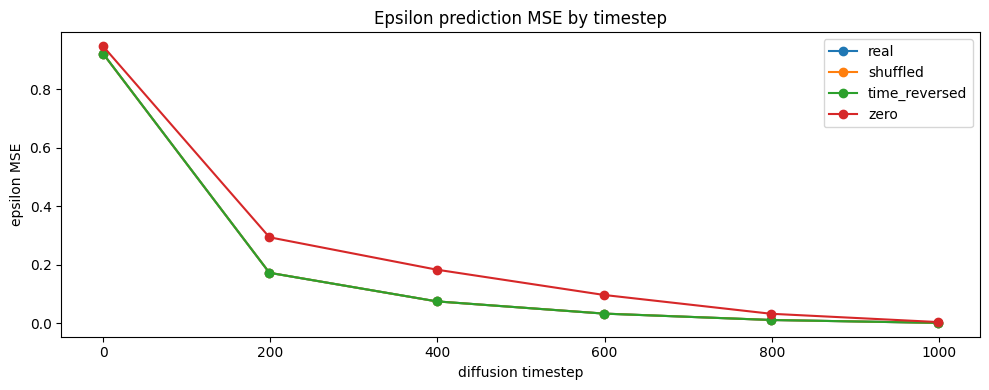

In [21]:
plt.figure(figsize=(10, 4))
for mode, group in flow_df.groupby("context_mode"):
    group = group.sort_values("tau")
    plt.plot(group["tau"], group["velocity_mse"], marker="o", label=mode)
plt.title("Flow velocity MSE by tau")
plt.xlabel("flow tau")
plt.ylabel("velocity MSE")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Sampling seed 안정성

같은 batch/context에서 초기 noise seed만 바꿨을 때 score와 latent가 얼마나 흔들리는지 봅니다.

- seed마다 score 분산이 크면 anomaly score가 sampling noise에 민감합니다.
- 모든 seed가 비슷하게 나쁘면 모델이 특정 분포로 수렴하거나 scale이 틀어진 상태일 수 있습니다.

In [22]:
seed_values = [DIAGNOSTIC_SEED, DIAGNOSTIC_SEED + 1, DIAGNOSTIC_SEED + 2]
seed_rows = []
seed_predictions = []
for seed in tqdm(seed_values, desc="sampling seeds"):
    prediction = generate_prediction("real", seed=seed)
    seed_predictions.append(prediction.detach().float().cpu())
    scores = per_frame_latent_scores(
        future,
        prediction,
        scoring=config.scoring,
        latent_stats=latent_stats,
    )
    seed_rows.append(
        {
            "seed": seed,
            "mse_to_future": tensor_mse(prediction, future),
            "configured_score_mean": float(scores.mean().detach().cpu()),
            "pred_rms": tensor_stats("prediction", prediction)["rms"],
        }
    )

seed_df = pd.DataFrame(seed_rows)
stacked_seed_predictions = torch.stack(seed_predictions, dim=0)
seed_variance_summary = {
    "mean_pixelwise_seed_std": float(stacked_seed_predictions.std(dim=0, unbiased=False).mean()),
    "mean_pairwise_prediction_mse": float(
        np.mean(
            [
                tensor_mse(seed_predictions[i], seed_predictions[j])
                for i in range(len(seed_predictions))
                for j in range(i + 1, len(seed_predictions))
            ]
        )
    ),
}
display(seed_df)
display(pd.DataFrame([seed_variance_summary]))

diagnostic_report["sampling_seed_stability"] = seed_df.to_dict("records")
diagnostic_report["sampling_seed_variance"] = seed_variance_summary

sampling seeds: 100%|██████████| 3/3 [00:00<00:00,  3.97it/s]


,seed,mse_to_future,configured_score_mean,pred_rms
0,42,695226.1875,1610573.875,833.906982
1,43,683449.8750,1575895.625,826.810669
2,44,734883.9375,1703146.500,857.357056


,mean_pixelwise_seed_std,mean_pairwise_prediction_mse
0,393.071503,599343.041667


## 8. 현재 batch의 frame-level score sanity check

소규모 batch에서 생성한 score를 metadata의 future frame label과 바로 매핑합니다. batch 안에 정상/이상이 모두 있으면 임시 AUC도 계산합니다.

In [23]:
def prediction_records_from_batch(prediction: torch.Tensor, variant: str) -> list[dict[str, Any]]:
    scores = per_frame_latent_scores(
        future,
        prediction,
        scoring=config.scoring,
        latent_stats=latent_stats,
    ).detach().cpu()
    records_out = []
    for index, sample in enumerate(batch["metadata"]):
        frames = [int(frame) for frame in sample["future_frames"]]
        labels = [int(label) for label in sample["future_frame_labels"]]
        frame_scores_out = [float(value) for value in scores[index].tolist()]
        records_out.append(
            {
                "sample_id": sample["sample_id"],
                "video_id": sample["video_id"],
                "variant": variant,
                "future_frames": frames,
                "future_frame_labels": labels,
                "future_frame_scores": frame_scores_out,
                "sample_score": float(np.mean(frame_scores_out)),
            }
        )
    return records_out

live_prediction_records = prediction_records_from_batch(pred_real, "real")
live_frame_scores = pd.DataFrame(aggregate_frame_scores(live_prediction_records))
display(live_frame_scores.head(20))

if not live_frame_scores.empty and live_frame_scores["label"].nunique() > 1:
    live_summary = score_metrics(
        live_frame_scores["label"].to_numpy(),
        live_frame_scores["score"].to_numpy(),
    )
else:
    live_summary = {
        "message": "batch 안에 정상/이상 label이 모두 없어 AUC를 계산하지 않았습니다.",
        "num_frames": int(len(live_frame_scores)),
        "num_anomaly_frames": int(live_frame_scores["label"].sum()) if not live_frame_scores.empty else 0,
    }

display(pd.DataFrame([live_summary]))
diagnostic_report["live_batch_score_summary"] = live_summary

,video_id,frame_idx,score,label,num_votes
0,01_0014,33,1.636007e+06,0,1
1,01_0014,34,1.663891e+06,0,1
2,01_0014,35,1.632165e+06,0,1
3,01_0014,36,1.615550e+06,0,1
4,01_0014,37,1.526166e+06,0,2
5,01_0014,38,1.603858e+06,0,2
6,01_0014,39,1.573787e+06,0,2
7,01_0014,40,1.577036e+06,0,2
8,01_0014,41,1.559478e+06,0,2
9,01_0014,42,1.556211e+06,0,2


,message,num_frames,num_anomaly_frames
0,batch 안에 정상/이상 label이 모두 없어 AUC를 계산하지 않았습니다.,20,0


## 9. 자동 체크 요약

아래 표는 빠르게 문제 위치를 좁히기 위한 heuristic입니다. 절대적인 판정이 아니라 다음 실험 우선순위를 정하는 용도입니다.

In [24]:
checks = []

if "latent_distribution" in diagnostic_report:
    dist_df = pd.DataFrame(diagnostic_report["latent_distribution"])
    real_rms = float(dist_df.loc[dist_df["name"] == "real_E_v", "rms"].iloc[0])
    pred_rms = float(dist_df.loc[dist_df["name"] == "pred_E_v_hat_real_context", "rms"].iloc[0])
    rms_ratio = pred_rms / max(real_rms, 1.0e-12)
    checks.append(
        {
            "check": "pred/real latent RMS ratio",
            "value": rms_ratio,
            "flag": bool(rms_ratio < 0.5 or rms_ratio > 2.0),
            "interpretation": "True면 flow sampling 또는 velocity scale 문제가 큼",
        }
    )

if "context_ablation" in diagnostic_report:
    ablation = pd.DataFrame(diagnostic_report["context_ablation"])
    real_error = float(ablation.loc[ablation["context_mode"] == "real", "mse_to_future"].iloc[0])
    zero_delta = float(
        ablation.loc[ablation["context_mode"] == "zero", "mse_to_real_context_prediction"].iloc[0]
    )
    shuffled_delta = float(
        ablation.loc[
            ablation["context_mode"] == "shuffled",
            "mse_to_real_context_prediction",
        ].iloc[0]
    )
    checks.append(
        {
            "check": "zero context delta / reconstruction error",
            "value": zero_delta / max(real_error, 1.0e-12),
            "flag": bool(zero_delta / max(real_error, 1.0e-12) < 0.05),
            "interpretation": "True면 sampling 출력이 E_c 변화에 거의 반응하지 않음",
        }
    )
    checks.append(
        {
            "check": "shuffled context delta / reconstruction error",
            "value": shuffled_delta / max(real_error, 1.0e-12),
            "flag": bool(shuffled_delta / max(real_error, 1.0e-12) < 0.05),
            "interpretation": "True면 sample 간 E_c 매칭이 출력에 거의 반영되지 않음",
        }
    )

if "flow_velocity_consistency" in diagnostic_report:
    velocity = pd.DataFrame(diagnostic_report["flow_velocity_consistency"])
    pivot = velocity.pivot_table(index="tau", columns="context_mode", values="velocity_mse")
    if "real" in pivot.columns and "zero" in pivot.columns:
        real_advantage = float((pivot["zero"] - pivot["real"]).mean())
        checks.append(
            {
                "check": "zero velocity MSE - real velocity MSE",
                "value": real_advantage,
                "flag": bool(real_advantage <= 0.0),
                "interpretation": "True면 real E_c가 zero context보다 velocity prediction에 도움이 된다고 보기 어려움",
            }
        )
    if "real" in pivot.columns and "shuffled" in pivot.columns:
        shuffled_advantage = float((pivot["shuffled"] - pivot["real"]).mean())
        checks.append(
            {
                "check": "shuffled velocity MSE - real velocity MSE",
                "value": shuffled_advantage,
                "flag": bool(shuffled_advantage <= 0.0),
                "interpretation": "True면 올바른 E_c 매칭의 이점이 약함",
            }
        )

if existing_summary:
    auc = float(existing_summary.get("roc_auc", float("nan")))
    inverted_auc = float(existing_summary.get("inverted_roc_auc", float("nan")))
    checks.append(
        {
            "check": "existing ROC-AUC < 0.5 and inverted higher",
            "value": inverted_auc - auc,
            "flag": bool(np.isfinite(auc) and np.isfinite(inverted_auc) and auc < 0.5 < inverted_auc),
            "interpretation": "True면 score 방향 또는 정상/이상 reconstruction 가정이 현재 artifact에서 뒤집혀 있음",
        }
    )

checks_df = pd.DataFrame(checks)
display(checks_df)
diagnostic_report["heuristic_checks"] = checks_df.to_dict("records")

,check,value,flag,interpretation
0,pred/real latent RMS ratio,1414.312306,True,True면 DDIM 생성 scale 또는 pred_x0 안정성 문제 가능성이 큼
1,zero context delta / reconstruction error,2.044225,False,True면 sampling 출력이 E_c 변화에 거의 반응하지 않음
2,shuffled context delta / reconstruction error,0.010538,True,True면 sample 간 E_c 매칭이 출력에 거의 반영되지 않음
3,zero epsilon MSE - real epsilon MSE,0.057195,False,True면 real E_c가 zero context보다 denoising에 도움이 ...
4,shuffled epsilon MSE - real epsilon MSE,0.000015,False,True면 올바른 E_c 매칭의 이점이 약함
5,existing ROC-AUC < 0.5 and inverted higher,0.157581,True,True면 score 방향 또는 정상/이상 reconstruction 가정이 현재 ...


## 10. 해석 가이드

- `pred/real latent RMS ratio`가 크게 벗어나면 flow sampling step 수, latent normalization, velocity target scale을 먼저 보세요.
- context ablation에서 real/zero/shuffled 출력 차이가 작으면 DiT가 `E_c`를 거의 쓰지 않는 상태입니다.
- velocity consistency에서 real context가 zero/shuffled보다 낫지만 Euler 생성이 나쁘면, `flow_matching.inference_steps`를 늘리거나 timestep distribution을 바꿔 확인할 수 있습니다.
- 기존 prediction AUC가 0.5보다 낮고 inverted AUC가 높으면 anomaly score 방향이 뒤집혔거나, 이상 구간이 정상보다 더 쉽게 평균 latent로 복원되는 데이터/모델 상태일 수 있습니다.

In [25]:
if SAVE_REPORT:
    report_path = PRED_DIR / "diagnostics_report.json"
    serializable_report = json.loads(json.dumps(diagnostic_report, default=str))
    write_json(report_path, serializable_report)
    print(f"wrote diagnostics report -> {report_path}")

wrote diagnostics report -> /workspace/VAD/data/04_predictions/shanghaitech/exp001/diagnostics_report.json
